In [1]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [17]:
#lets get more complex
a = 2.0
b= -3.0
c = 10
d = a*b+c
d

4.0

In [18]:
h = 0.0001

# inputs
a = 2.0
b=-3.0
c=10
d1 = a*b +c
a += h
d2 = a*b+c
print("d1", d1)
print("d2", d2)
print("slove:",(d2-d1)/h)

d1 4.0
d2 3.999699999999999
slove: -3.000000000010772


In [ ]:
class Value():
    def __init__(self,data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label= label
    def __repr__(self):
        return f"Value(data = {self.data})"
    def __add__(self, other):
        out = Value(self.data + other.data, (self,other), '+')
        
        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
            
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self,other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
            
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward():
            self.grad += (1-t**2) * out.grad
        
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    
    


Value(data = -8.0)

In [12]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s |  data %.4f | grad %4f}" % (n.label, n.data, n.grad ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
            
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

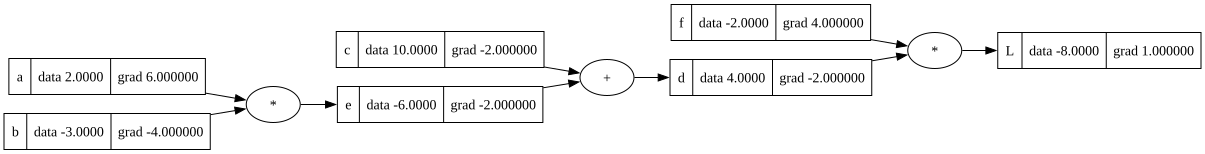

In [53]:
draw_dot(L)

In [ ]:
def lol():
    h = 0.0001
    
    a = Value(2.0,label='a')
    b = Value(-3.0,label='b')
    c = Value(10.0, label='c')
    e = a*b ; e.label='e'
    #(a.__mull__(b)).__ad__(c)
    d=e+c ; d.label='d'
    f = Value(-2.0, label='f')
    L = d*f ; L.label = 'L'
    L1 = L.data
    
    a = Value(2.0 + h,label='a')
    b = Value(-3.0,label='b')
    c = Value(10.0, label='c')
    e = a*b ; e.label='e'
    #(a.__mull__(b)).__ad__(c)
    d=e+c ; d.label='d'
    f = Value(-2.0, label='f')
    L = d*f ; L.label = 'L'
    L2 = L.data
    
    print((L2-L1)/h)

lol()

6.000000000021544


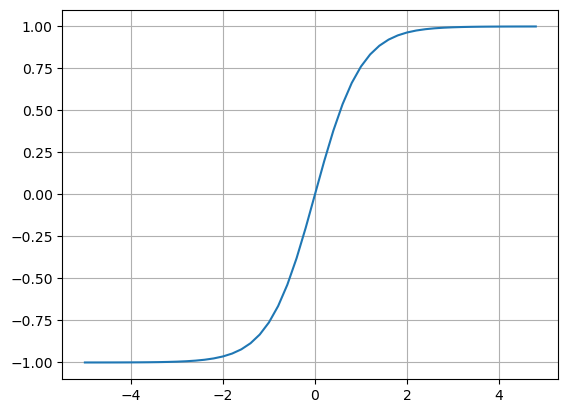

In [56]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))) ; plt.grid()

In [52]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.888888, label='b')
# x1*w1 + x2*w2 + b 
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh() ; o.label = 'o'

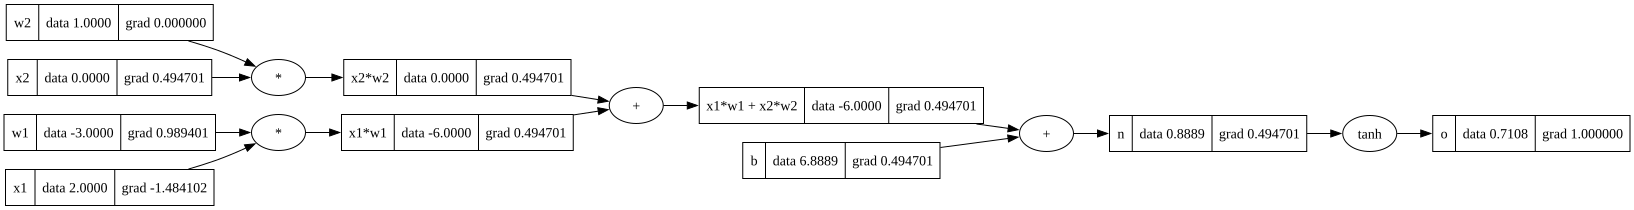

In [48]:
draw_dot(o)

In [47]:
o.backward()

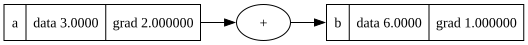

In [53]:
a = Value(3.0, label='a')
b = a + a   ; b.label = 'b'
b.backward()
draw_dot(b)

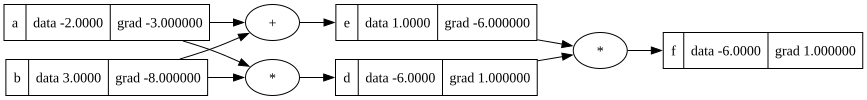

In [54]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b   ; d.label = 'd'
e = a + b   ; e.label = 'e'
f = d * e   ; f.label = 'f'

f.backward()

draw_dot(f)